**import required libraries**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

**Load YOLO Model**

In [13]:
model = YOLO("yolov8n.pt")

print("Model loaded successfully")

Model loaded successfully


**Dataset Path**

In [14]:
# Traffic Image Dataset Path
CURRENT_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(CURRENT_DIR)

TRAFFIC_PATH = os.path.join(PROJECT_ROOT,"Datasets","Traffic_images")

print("Traffic Image Folder:", TRAFFIC_PATH)

images = os.listdir(TRAFFIC_PATH)

print("Total Images:", len(images))

Traffic Image Folder: C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\Traffic_images
Total Images: 12


**Car Colour Detection Function**

In [19]:
def detect_car_color(car_img):

    hsv = cv2.cvtColor(car_img, cv2.COLOR_BGR2HSV)

    # Improved blue range
    lower_blue = np.array([100,150,50])
    upper_blue = np.array([140,255,255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    blue_pixels = cv2.countNonZero(mask)

    total_pixels = car_img.shape[0] * car_img.shape[1]

    blue_ratio = blue_pixels / total_pixels

    # Only classify as blue if large portion is blue
    if blue_ratio > 0.20:
        return "Blue"
    else:
        return "Other"

**Frame Processing Function**

In [20]:
# Process Frame
def process_frame(frame):

    results = model(frame)

    people_count = 0
    car_count = 0

    for r in results:

        boxes = r.boxes

        for box in boxes:

            cls = int(box.cls)
            label = model.names[cls]

            x1,y1,x2,y2 = map(int,box.xyxy[0])

            # Person Detection
            if label == "person":

                people_count += 1

                cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)

                cv2.putText(frame,"Person",(x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7,(0,255,0),2)
                
            # Car Detection
            if label == "car":

                car_count += 1

                car_img = frame[y1:y2,x1:x2]

                color = detect_car_color(car_img)

                # Blue car → Red rectangle
                if color == "Blue":

                    cv2.rectangle(frame,(x1,y1),(x2,y2),(0,0,255),2)

                    cv2.putText(frame,"Blue Car",(x1,y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.7,(0,0,255),2)

                # Other cars → Blue rectangle
                else:

                    cv2.rectangle(frame,(x1,y1),(x2,y2),(255,0,0),2)

                    cv2.putText(frame,"Car",(x1,y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.7,(255,0,0),2)

    return frame, people_count, car_count

**Test With One Sample Image**


0: 480x640 37 cars, 1 motorcycle, 1 bus, 1 truck, 123.7ms
Speed: 5.2ms preprocess, 123.7ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)
Cars detected: 37
People detected: 0


(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

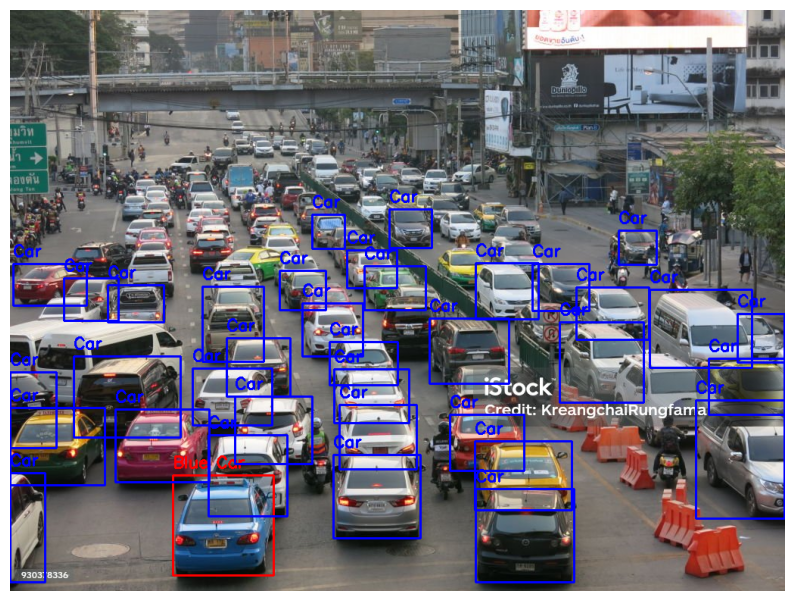

In [31]:
# Test With One Image
sample_image = os.path.join(TRAFFIC_PATH, images[8])

frame = cv2.imread(sample_image)

frame, people, cars = process_frame(frame)

print("Cars detected:", cars)
print("People detected:", people)

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")